In [1]:
from scripts.s1_rvl import compute_rvl, compute_rvl_gamma
import numpy as np
from matplotlib import pyplot as plt
import os
import xarray as xr

%matplotlib widget

In [2]:
data_dir = 'data/S1_data/test2'

slc_paths     = sorted(f'{data_dir}/{f}' for f in os.listdir(data_dir) if f.endswith('.slc'))
slc_par_paths = sorted(f'{data_dir}/{f}' for f in os.listdir(data_dir) if f.endswith('.slc.par'))

In [3]:
gamma_rvl = compute_rvl_gamma(slc_paths, slc_par_paths, 'data/S1_data/test2/S1A_IW_SLC__1SDV_20260205T165251_20260205T165321_063086_07EAEF_2642.SAFE/annotation/s1a-iw1-slc-vv-20260205t165251-20260205t165319-063086-07eaef-004.xml', stride_az=64, stride_rg=128)

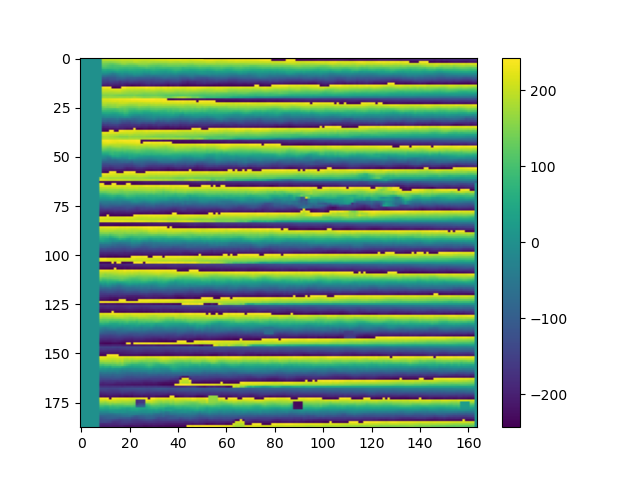

In [11]:
plt.close()
plt.imshow(gamma_rvl['f_dc'].values, aspect='auto')
plt.colorbar()
plt.show()

In [4]:
# gamma_rvl = compute_rvl_gamma('data/S1_data/test2/iw1_vv_burst8.slc', 'data/S1_data/test2/iw1_vv_burst8.slc.par', 'data/S1_data/test2/S1A_IW_SLC__1SDV_20260205T165251_20260205T165321_063086_07EAEF_2642.SAFE/annotation/s1a-iw1-slc-vv-20260205t165251-20260205t165319-063086-07eaef-004.xml', stride_az=64, stride_rg=128)

In [20]:
rvl = compute_rvl('data/S1_data/test2/S1A_IW_SLC__1SDV_20260205T165251_20260205T165321_063086_07EAEF_2642.SAFE', 'iw1', stride_az=64, stride_rg=128, do_descallop=False)

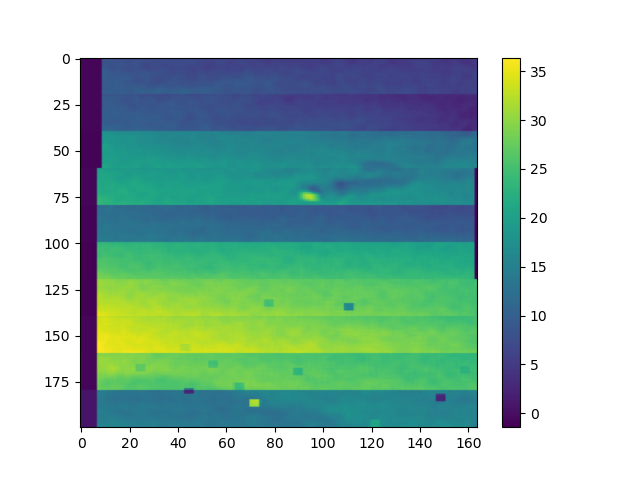

In [21]:
plt.close()
plt.imshow(rvl['doppler_hz'].values, aspect='auto')
plt.colorbar()
plt.show()

In [21]:
ocn_prod = xr.open_dataset('data/S1_data/test2/S1A_IW_OCN__2SDV_20260205T165251_20260205T165320_063086_07EAEF_420C.SAFE/measurement/s1a-iw-ocn-vv-20260205t165251-20260205t165322-063086-07EAEF-001.nc')

In [22]:
dc_obs = ocn_prod['rvlDcObs']
dc_geo = ocn_prod['rvlDcGeo']
dc_miss = ocn_prod['rvlDcMiss']

dc_corr = dc_obs-dc_geo-dc_miss

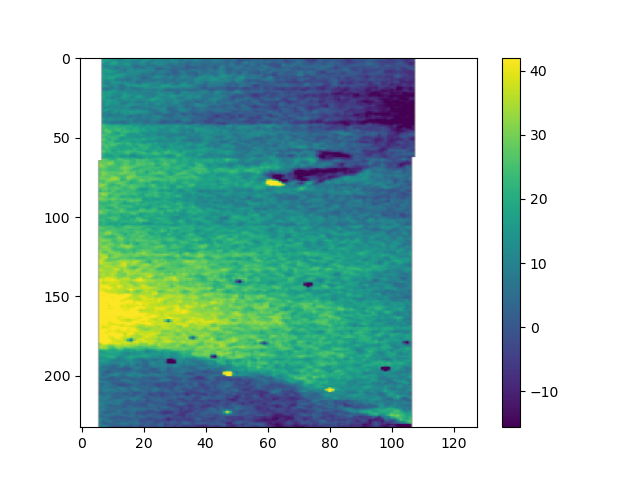

In [27]:
plt.close()
plt.imshow(dc_obs.values[...,0], vmin=np.nanquantile(dc_obs.values[...,0], 0.01), vmax=np.nanquantile(dc_obs.values[...,0], 0.99), aspect='auto')
plt.colorbar()
plt.show()

In [11]:
from scripts import s1_ocn
import matplotlib.pyplot as plt

In [12]:
SAFE_PATH = 'data/S1_data/test2/S1A_IW_OCN__2SDV_20260205T165251_20260205T165320_063086_07EAEF_420C.SAFE'

pro = s1_ocn.retrieve_radial_current(SAFE_PATH, polarisation='vv', swath_index=0)

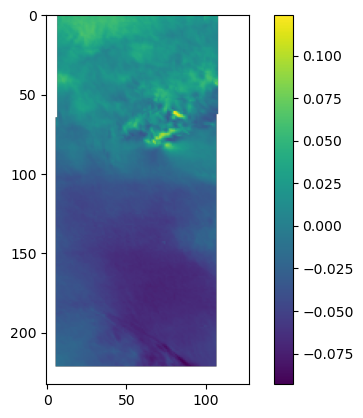

In [13]:
plt.close()
plt.imshow(ocn_prod['rvlRadVel'].values[...,0] - pro['currentRadVel'].values)
plt.colorbar()

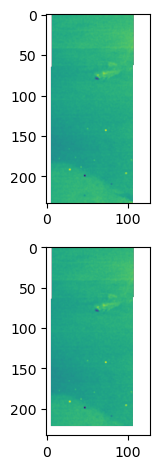

In [14]:
plt.close()
fig,ax = plt.subplots(2,1)

ax[0].imshow(ocn_prod['rvlRadVel'].values[...,0])

ax[1].imshow(pro['currentRadVel'].values)

plt.tight_layout()
plt.show()